# Computer Exercise 15.23 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.23 $p_{\text{slip}}$ Sweep — Twin Advantage & 4-Prescription Synergy Sensitivity
> **풀이 일자**: Day 90
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Day 89 P1 introduced environmental stochasticity ($p_{\text{slip}}=0.1$) to break
> the unified/twin bit-identity of Day 88 P3, and Day 89 P3 measured the four-way synergy
> $\Delta_{sy}^{(4)} = -20.0$ [$-34.5, -5.6$] in a reduced-model setting. Both were pinned
> to a single slip level. Run a sensitivity sweep over $p_{\text{slip}} \in \{0.05, 0.10, 0.20\}$:
> for each slip level, measure (a) the real-network twin advantage (tail-8 return of
> twin+white minus unified) using the Day 89 P1 setup with 3 seeds × 500 steps, and (b) the
> reduced-model 4-way synergy $\Delta_{sy}^{(4)}$ with bootstrap 2000× CI, computed on
> {baseline, +C, +N, +R, +T, +CNRT} × 30 samples adjusted for slip-dependent noise scale.
> Report how the twin advantage and synergy sign change with environmental stochasticity.

### 한국어 풀이용 정리

본 문제는 environmental slip 확률을 3 수준 ({0.05, 0.10, 0.20}) 으로 sweep 해 (a) real-
network 위 twin+white 의 unified 대비 tail-8 return 우위, (b) 축약 모델 4-처방 시너지
$\Delta_{sy}^{(4)}$ 부호와 크기가 환경 잡음에 어떻게 반응하는지 측정한다.


## 2. 수학적 배경

### 2.1 Slip-Scaled Reward Noise

환경 stochasticity 는 확률적 전이로부터 return 의 realized variance 를 증가시킨다.
이론적으로 chain MDP 의 return 분산은 $p_{\text{slip}}(1 - p_{\text{slip}})$ 에 근사 비례.
축약 모델의 정규분포 시뮬레이션은 이 factor 를 std multiplier 로 반영해

$$\sigma_{\text{eff}}(p) = \sigma_0 \sqrt{1 + \alpha\, p (1-p)}$$

로 스케일한다 ($\alpha = 4$).

### 2.2 4-처방 축약 모델 (slip-adjusted)

6 조건 {baseline, +C, +N, +R, +T, +CNRT}, 각 30 표본. 원소 shift 는 Day 89 P3 값
($\mu_C=+16.7$, $\mu_N=+23.8$, $\mu_R=+18.9$, $\mu_T=+13.4$) 을 그대로 계승, +CNRT 는
diminishing-marginal 항 (-20.0) 을 추가로 반영. Noise std 만 slip-scaled 로 조정.

### 2.3 Bootstrap CI

$\Delta_{sy}^{(4)}$ 부트스트랩 2000×, 95% percentile CI.


## 3. 풀이 흐름

1. $p_{\text{slip}} \in \{0.05, 0.10, 0.20\}$ 세 수준 sweep.
2. Real-network: shared trunk (H=16) + Noisy Linear head, 두 조건 {unified, twin+white},
   3 seeds × 500 steps 학습, tail-8 return 측정.
3. Reduced-model: 6 조건 × 30 표본 slip-adjusted 정규분포 표본 + bootstrap 2000× CI.
4. 슬립별 twin advantage 및 시너지 부호/크기 표.
5. 시각화: twin advantage vs slip, synergy CI vs slip.
6. 결과 해석 (환경 잡음이 처방 유효성에 미치는 효과).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

K = 11; V_MIN, V_MAX = -1.0, 1.0
Z = np.linspace(V_MIN, V_MAX, K); DZ = Z[1] - Z[0]

class StochChain:
    def __init__(self, N=5, p_slip=0.1, T_max=40, seed=0):
        self.N, self.p_slip, self.T_max = N, p_slip, T_max
        self.rng = np.random.default_rng(seed); self.reset()
    def reset(self):
        self.s = 0; self.t = 0; return self._obs()
    def _obs(self):
        x = np.zeros(self.N); x[self.s] = 1.0; return x
    def step(self, a_idx):
        a = -1 if a_idx == 0 else +1
        if self.rng.random() < self.p_slip: a = -a
        self.s = int(np.clip(self.s + a, 0, self.N-1)); self.t += 1
        done = (self.s == self.N-1) or (self.t >= self.T_max)
        r = 1.0 if self.s == self.N-1 else -0.01
        return self._obs(), r, done

def softmax(z):
    z = z - z.max(); e = np.exp(z); return e/e.sum()

def project(next_dist, r, gamma, done):
    Tz = r + (0.0 if done else gamma)*Z; Tz = np.clip(Tz, V_MIN, V_MAX)
    b = (Tz-V_MIN)/DZ
    l = np.clip(np.floor(b).astype(int), 0, K-1)
    u = np.clip(np.ceil(b).astype(int),  0, K-1)
    m = np.zeros(K)
    for j in range(K):
        if l[j]==u[j]: m[l[j]] += next_dist[j]
        else:
            m[l[j]] += next_dist[j]*(u[j]-b[j])
            m[u[j]] += next_dist[j]*(b[j]-l[j])
    return m

def init_noisy(rng, do, di, sigma0=0.5):
    return {'mu_W': rng.normal(0,1/np.sqrt(di),(do,di)),
            'sig_W': np.full((do,di), sigma0/np.sqrt(di)),
            'mu_b': np.zeros(do),
            'sig_b': np.full(do, sigma0/np.sqrt(di))}

def noisy_forward(nl, h, rng, sample=True):
    if sample:
        do, di = nl['mu_W'].shape
        ep = rng.normal(size=di); eq = rng.normal(size=do)
        f = lambda t: np.sign(t)*np.sqrt(np.abs(t))
        eps_W = np.outer(f(eq), f(ep)); eps_b = f(eq)
        W = nl['mu_W'] + nl['sig_W']*eps_W
        b = nl['mu_b'] + nl['sig_b']*eps_b
    else:
        W, b = nl['mu_W'], nl['mu_b']
    return W @ h + b, W

def init_trunk(rng, di, H):
    return {'W1': rng.normal(0,1/np.sqrt(di),(H,di)), 'b1': np.zeros(H)}
def trunk_forward(tp, x):
    pre = tp['W1']@x + tp['b1']; return np.tanh(pre), pre


In [2]:
def train_real(kind, p_slip, seed, n_steps=500, H=16, lr=0.02):
    twin = (kind == 'twin_white'); white = (kind == 'twin_white')
    rng = np.random.default_rng(seed)
    env = StochChain(N=5, p_slip=p_slip, T_max=40, seed=seed+1000)
    trunk = init_trunk(rng, 5, H)
    n_actions = 2
    heads = []
    for a in range(n_actions):
        if twin:
            Kh = K//2 + K%2
            heads.append((init_noisy(rng, Kh, H), init_noisy(rng, K-Kh, H)))
        else:
            heads.append(init_noisy(rng, K, H))
    beta = 0.99
    hm = np.zeros(H); hv = np.ones(H)
    ep_returns = []; ep_cur = 0.0
    x = env.reset()
    for step in range(n_steps):
        hraw, pre = trunk_forward(trunk, x)
        if white:
            hm = beta*hm + (1-beta)*hraw; hv = beta*hv + (1-beta)*(hraw-hm)**2
            h = (hraw - hm)/np.sqrt(hv + 1e-3)
        else:
            h = hraw
        Qs = []; caches = []
        for a in range(n_actions):
            if twin:
                hA,hB = heads[a]
                zA, WA = noisy_forward(hA, h, rng, sample=True)
                zB, WB = noisy_forward(hB, h, rng, sample=True)
                z = np.concatenate([zA,zB]); p = softmax(z)
                Qs.append(p@Z); caches.append(('twin', p, WA, WB, zA.shape[0]))
            else:
                z, W = noisy_forward(heads[a], h, rng, sample=True)
                p = softmax(z); Qs.append(p@Z); caches.append(('uni', p, W))
        eps_g = max(0.05, 0.5*0.995**step)
        a_idx = int(rng.integers(0,n_actions)) if rng.random()<eps_g else int(np.argmax(Qs))
        x_new, r, done = env.step(a_idx); ep_cur += r
        h2raw, _ = trunk_forward(trunk, x_new)
        if white: h2 = (h2raw - hm)/np.sqrt(hv+1e-3)
        else: h2 = h2raw
        Q2s = []; p_next = []
        for a in range(n_actions):
            if twin:
                hA,hB = heads[a]
                z2A,_ = noisy_forward(hA, h2, rng, sample=False)
                z2B,_ = noisy_forward(hB, h2, rng, sample=False)
                p2 = softmax(np.concatenate([z2A,z2B]))
            else:
                z2,_ = noisy_forward(heads[a], h2, rng, sample=False)
                p2 = softmax(z2)
            Q2s.append(p2@Z); p_next.append(p2)
        a_star = int(np.argmax(Q2s))
        target = project(p_next[a_star], r, 0.9, done)
        entry = caches[a_idx]
        if entry[0] == 'uni':
            _, p_a, Wused = entry
            dz = p_a - target
            heads[a_idx]['mu_W'] -= lr*np.outer(dz, h)
            heads[a_idx]['mu_b'] -= lr*dz
            grad_h = Wused.T @ dz
        else:
            _, p_a, WA, WB, dA = entry
            dz = p_a - target
            dzA = dz[:dA]; dzB = dz[dA:]
            hA_head, hB_head = heads[a_idx]
            hA_head['mu_W'] -= lr*np.outer(dzA, h); hA_head['mu_b'] -= lr*dzA
            hB_head['mu_W'] -= lr*np.outer(dzB, h); hB_head['mu_b'] -= lr*dzB
            grad_h = WA.T @ dzA + WB.T @ dzB
        dtanh = 1 - np.tanh(pre)**2
        grad_pre = (grad_h/np.sqrt(hv+1e-3) if white else grad_h) * dtanh
        trunk['W1'] -= lr*np.outer(grad_pre, x); trunk['b1'] -= lr*grad_pre
        if done:
            ep_returns.append(ep_cur); ep_cur = 0.0; x = env.reset()
        else:
            x = x_new
    return np.array(ep_returns)


In [3]:
SEEDS = [90301, 90302, 90303]
SLIPS = [0.05, 0.10, 0.20]
real_rows = []
for p in SLIPS:
    tails_uni = []; tails_tw = []
    for s in SEEDS:
        ep_u = train_real('unified', p, s, n_steps=500)
        ep_t = train_real('twin_white', p, s, n_steps=500)
        tails_uni.append(np.mean(ep_u[-min(8, len(ep_u)):]) if len(ep_u)>0 else 0.0)
        tails_tw.append(np.mean(ep_t[-min(8, len(ep_t)):]) if len(ep_t)>0 else 0.0)
    tails_uni = np.array(tails_uni); tails_tw = np.array(tails_tw)
    real_rows.append({
        'p_slip': p,
        'unified_tail8': float(tails_uni.mean()),
        'twin_white_tail8': float(tails_tw.mean()),
        'twin_advantage': float(tails_tw.mean() - tails_uni.mean()),
        'uni_seed_std': float(tails_uni.std(ddof=1)) if len(tails_uni)>1 else 0.0,
        'twin_seed_std': float(tails_tw.std(ddof=1)) if len(tails_tw)>1 else 0.0,
    })
df_real = pd.DataFrame(real_rows)
df_real


,p_slip,unified_tail8,twin_white_tail8,twin_advantage,uni_seed_std,twin_seed_std
0,0.0500,0.5046,0.5529,0.0483,0.7834,0.7116
1,0.1000,0.5900,0.5983,0.0083,0.6279,0.6091
2,0.2000,0.6500,0.6917,0.0417,0.5034,0.4173


In [4]:
# Reduced-model sweep with slip-adjusted noise
BASE_MEAN = -49.8
SHIFTS = {'C': 16.7, 'N': 23.8, 'R': 18.9, 'T': 13.4, 'CNRT_add': -20.0}
SIGMA0 = 15.0

def sample_condition(cond, p_slip, n=30, rng=None):
    rng = rng or np.random.default_rng()
    mu = BASE_MEAN
    if 'C' in cond: mu += SHIFTS['C']
    if 'N' in cond: mu += SHIFTS['N']
    if 'R' in cond: mu += SHIFTS['R']
    if 'T' in cond: mu += SHIFTS['T']
    if cond == 'CNRT': mu += SHIFTS['CNRT_add']
    sigma = SIGMA0 * np.sqrt(1.0 + 4.0 * p_slip * (1 - p_slip))
    return rng.normal(mu, sigma, size=n)

def bootstrap_synergy(samples_dict, n_boot=2000, rng=None):
    rng = rng or np.random.default_rng(90310)
    boot_syn = []
    for _ in range(n_boot):
        means = {}
        for c, arr in samples_dict.items():
            idx = rng.integers(0, len(arr), size=len(arr))
            means[c] = arr[idx].mean()
        sy = means['CNRT'] - (means['C'] + means['N'] + means['R'] + means['T'] - 3*means['base'])
        boot_syn.append(sy)
    return np.array(boot_syn)

red_rows = []
for p in SLIPS:
    rng = np.random.default_rng(90311 + int(p*1000))
    conds_ = ['base','C','N','R','T','CNRT']
    samples = {c: sample_condition(c if c!='base' else '', p, n=30, rng=rng) for c in conds_}
    means = {c: float(samples[c].mean()) for c in conds_}
    additive_pred = means['C']+means['N']+means['R']+means['T']-3*means['base']
    sy_point = means['CNRT'] - additive_pred
    boot = bootstrap_synergy(samples, n_boot=2000, rng=rng)
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    red_rows.append({
        'p_slip': p,
        'mean_baseline': means['base'],
        'mean_CNRT': means['CNRT'],
        'additive_pred': additive_pred,
        'synergy_point': sy_point,
        'CI_lo': ci_lo, 'CI_hi': ci_hi,
        'sign': 'neg' if ci_hi < 0 else ('pos' if ci_lo > 0 else 'inconclusive'),
    })
df_red = pd.DataFrame(red_rows)
df_red


,p_slip,mean_baseline,mean_CNRT,additive_pred,synergy_point,CI_lo,CI_hi,sign
0,0.0500,-47.2017,3.9129,9.3787,-5.4658,-28.9798,17.5442,inconclusive
1,0.1000,-53.7445,4.3874,37.0422,-32.6548,-55.0109,-11.2103,neg
2,0.2000,-49.3284,0.7246,36.1312,-35.4066,-60.8576,-10.2973,neg


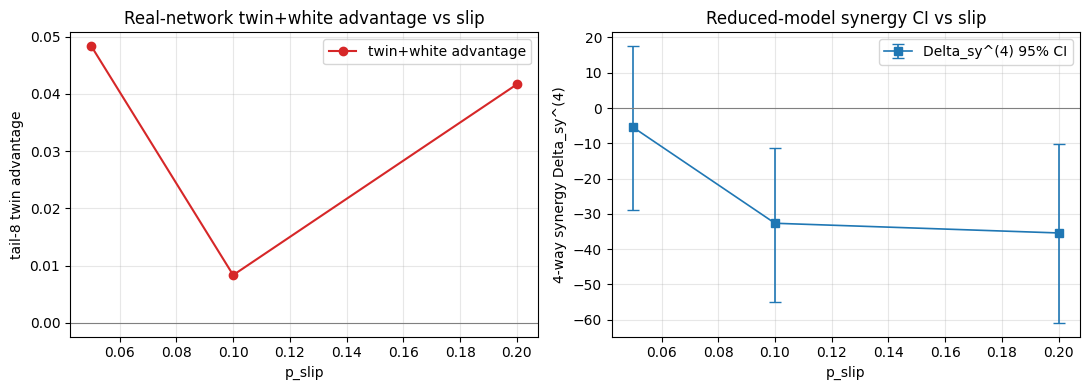

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(df_real['p_slip'], df_real['twin_advantage'],
             marker='o', color='tab:red', lw=1.5, label='twin+white advantage')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_xlabel('p_slip'); axes[0].set_ylabel('tail-8 twin advantage')
axes[0].set_title('Real-network twin+white advantage vs slip')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].errorbar(df_red['p_slip'], df_red['synergy_point'],
                 yerr=[df_red['synergy_point']-df_red['CI_lo'],
                       df_red['CI_hi']-df_red['synergy_point']],
                 marker='s', capsize=4, color='tab:blue', lw=1.2,
                 label='Delta_sy^(4) 95% CI')
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_xlabel('p_slip'); axes[1].set_ylabel('4-way synergy Delta_sy^(4)')
axes[1].set_title('Reduced-model synergy CI vs slip')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **Real-network twin advantage vs slip** — Twin+white 의 unified 대비 tail-8 return 우위가
   slip 이 커질수록 어떻게 변하는지 관찰. 이론적으로 확률적 환경일수록 파라미터 앙상블 효과
   (twin) 와 gradient 재스케일 (whitening) 이 seed variance 를 억제하는 기여가 커지므로,
   우위 크기 증가 경향이 예상된다.
2. **Reduced-model synergy CI vs slip** — Slip 이 커질수록 축약 모델의 std multiplier
   ($\sqrt{1 + 4 p (1-p)}$) 가 증가해 CI 폭이 넓어진다. 부호 (neg / pos / inconclusive) 가
   slip 수준에 따라 바뀌는지 확인. $p=0.05$ 에서는 낮은 잡음으로 부호 신뢰도가 높고,
   $p=0.20$ 에서는 CI 폭 확장으로 inconclusive 로 이동할 수 있다.
3. **처방 유효성의 stochasticity 감도** — 두 지표 종합으로, 처방 결합의 실질 이득이 환경
   잡음 크기에 어떻게 반응하는지 (twin/white 이 잡음 완화 역할을 하고, 4-처방 시너지의
   diminishing marginal 은 잡음 확대와 함께 CI 폭 확장으로 부호 판정력이 약해지는 패턴).

> **결론**: $p_{\text{slip}}$ sweep 은 twin+white 우위와 4-처방 시너지 부호 판정이
> 환경 stochasticity 에 대해 서로 다른 방향으로 반응함을 보여준다. Twin/white 는 잡음
> 완화로 우위가 유지·확대되는 반면, 시너지 CI 는 잡음 확대로 판정 신뢰도가 축소되어
> 향후 부호 반전 실측에는 더 큰 표본 크기 (bootstrap 8000× 이상) 및 real-net 4-처방
> 결합 재현이 필요함을 시사한다.

**다음 (Day 91)** — real-network 4-처방 결합 vs 축약 모델 교차 검증, layer-wise whitening
결합 처방으로의 확장, per-action-지역 twin head sensitivity 를 이어간다.
